# 04 Model Training

Train tuned baseline models, compare them with a weighted hybrid and a stacked ensemble, and save report-ready tables and figures.

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from evaluation import (
    blend_probabilities,
    build_precision_recall_curve_df,
    evaluate_predictions,
    evaluate_with_best_f1_threshold,
    find_threshold_for_target_precision,
)
from models import (
    tune_lightgbm_baseline,
    tune_logistic_regression_baseline,
    tune_mlp_baseline,
    tune_random_forest_baseline,
)

In [6]:
processed_dir = PROJECT_ROOT / "data" / "processed"
tables_dir = PROJECT_ROOT / "outputs" / "tables"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_linear = pd.read_parquet(processed_dir / "train_linear_ready.parquet")
train_tree = pd.read_parquet(processed_dir / "train_tree_ready.parquet")

print("Linear-ready shape:", train_linear.shape)
print("Tree-ready shape:", train_tree.shape)

Linear-ready shape: (307511, 612)
Tree-ready shape: (307511, 612)


## Tuned Baseline Models

In [ ]:
log_reg_param_grid = {
    "C": [0.1, 1.0, 5.0],
}

# frozen one-config fallback from best run:
# log_reg_param_grid = {
#     "C": [1.0],
# }

log_reg_model, log_reg_results, y_train_log_reg, log_reg_train_probs, y_val_log_reg, log_reg_probs, log_reg_tuning_results, best_log_reg_params = tune_logistic_regression_baseline(
    param_grid=log_reg_param_grid
)

print("Best Logistic Regression params:", best_log_reg_params)
print("Logistic Regression Results:")
for metric, value in log_reg_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")


Best Logistic Regression params: {'C': 1.0}
Logistic Regression Results:
accuracy: 0.7119
precision: 0.1759
recall: 0.6971
f1: 0.2809
roc_auc: 0.7754
average_precision: 0.2660


In [ ]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [12, 20, None],
    "min_samples_leaf": [5, 10],
    "min_samples_split": [10, 20],
}

# frozen one-config fallback from best run:
# rf_param_grid = {
#     "n_estimators": [400],
#     "max_depth": [None],
#     "min_samples_leaf": [10],
#     "min_samples_split": [10],
# }

rf_model, rf_results, y_train_rf, rf_train_probs, y_val_rf, rf_probs, rf_tuning_results, best_rf_params = tune_random_forest_baseline(
    param_grid=rf_param_grid
)

print("Best Random Forest params:", best_rf_params)
print("Random Forest Results:")
for metric, value in rf_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")


Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 400}
Random Forest Results:
accuracy: 0.9112
precision: 0.3814
recall: 0.1603
f1: 0.2258
roc_auc: 0.7708
average_precision: 0.2543


In [ ]:
lgbm_param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 64, 96],
    "min_child_samples": [20, 50],
}

# frozen one-config fallback from best run:
# lgbm_param_grid = {
#     "learning_rate": [0.05],
#     "min_child_samples": [50],
#     "n_estimators": [500],
#     "num_leaves": [31],
# }

lgbm_model, lgbm_results, y_train_lgbm, lgbm_train_probs, y_val_lgbm, lgbm_probs, lgbm_tuning_results, best_lgbm_params = tune_lightgbm_baseline(
    param_grid=lgbm_param_grid
)

print("Best LightGBM params:", best_lgbm_params)
print("LightGBM Results:")
for metric, value in lgbm_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")


Best LightGBM params: {'learning_rate': 0.05, 'min_child_samples': 50, 'n_estimators': 500, 'num_leaves': 31}
LightGBM Results:
accuracy: 0.7543
precision: 0.1980
recall: 0.6699
f1: 0.3057
roc_auc: 0.7888
average_precision: 0.2911


In [ ]:
mlp_param_grid = {
    "hidden_dims": [(256, 128), (128, 64), (256, 64)],
    "dropout": [0.2, 0.3],
    "learning_rate": [0.001, 0.0005],
    "epochs": [15, 20],
}

# frozen one-config fallback from best run:
# mlp_param_grid = {
#     "hidden_dims": [(256, 64)],
#     "dropout": [0.3],
#     "learning_rate": [0.0005],
#     "epochs": [15],
# }

mlp_model, mlp_results, mlp_history, y_train_mlp, mlp_train_probs, y_val_mlp, mlp_probs, mlp_tuning_results, best_mlp_params = tune_mlp_baseline(
    param_grid=mlp_param_grid
)

print("Best Neural Network params:", best_mlp_params)
print("Neural Network Results:")
for metric, value in mlp_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")

mlp_history.tail()


Best Neural Network params: {'dropout': 0.3, 'epochs': 15, 'hidden_dims': (256, 64), 'learning_rate': 0.0005}
Neural Network Results:
accuracy: 0.7060
precision: 0.1748
recall: 0.7102
f1: 0.2806
roc_auc: 0.7719
average_precision: 0.2718


,epoch,train_loss
10,11,0.977645
11,12,0.967618
12,13,0.957004
13,14,0.942551
14,15,0.934423


## Weighted Hybrid

The weighted hybrid is the project's novel contribution. It blends tuned Logistic Regression and tuned LightGBM validation probabilities with a fixed weight sweep.

In [12]:
hybrid_y_val = y_val_log_reg.reset_index(drop=True)
if not hybrid_y_val.equals(y_val_lgbm.reset_index(drop=True)):
    raise ValueError("Validation labels do not align between Logistic Regression and LightGBM.")

hybrid_rows = []
for lgbm_weight in [0.50, 0.60, 0.70, 0.80, 0.90]:
    hybrid_probs_candidate = blend_probabilities(lgbm_probs, log_reg_probs, primary_weight=lgbm_weight)
    default_metrics = evaluate_predictions(hybrid_y_val, hybrid_probs_candidate)
    tuned_metrics = evaluate_with_best_f1_threshold(hybrid_y_val, hybrid_probs_candidate)
    hybrid_rows.append(
        {
            "lgbm_weight": lgbm_weight,
            "log_reg_weight": 1 - lgbm_weight,
            "roc_auc": default_metrics["roc_auc"],
            "average_precision": default_metrics["average_precision"],
            "default_f1": default_metrics["f1"],
            "tuned_f1": tuned_metrics["f1"],
            "tuned_precision": tuned_metrics["precision"],
            "tuned_recall": tuned_metrics["recall"],
            "tuned_threshold": tuned_metrics["threshold"],
        }
    )

hybrid_weight_df = pd.DataFrame(hybrid_rows)
hybrid_weight_df = hybrid_weight_df.sort_values(["roc_auc", "tuned_f1"], ascending=False).reset_index(drop=True)
hybrid_weight_df

,lgbm_weight,log_reg_weight,roc_auc,average_precision,default_f1,tuned_f1,tuned_precision,tuned_recall,tuned_threshold
0,0.8,0.2,0.790146,0.294216,0.305682,0.346709,0.295927,0.418530,0.68
1,0.7,0.3,0.790080,0.294251,0.304200,0.345351,0.278900,0.453374,0.66
2,0.9,0.1,0.789718,0.293229,0.306513,0.345937,0.280748,0.450554,0.66
3,0.6,0.4,0.789521,0.293376,0.301773,0.345089,0.301719,0.403021,0.69
4,0.5,0.5,0.788451,0.291506,0.299035,0.343609,0.289235,0.423162,0.68


In [13]:
best_hybrid_row = hybrid_weight_df.iloc[0]
best_lgbm_weight = float(best_hybrid_row["lgbm_weight"])
hybrid_probs = blend_probabilities(lgbm_probs, log_reg_probs, primary_weight=best_lgbm_weight)

hybrid_results = {
    "model": f"Hybrid (LGBM {best_lgbm_weight:.1f} + LR {1 - best_lgbm_weight:.1f})",
    **evaluate_predictions(hybrid_y_val, hybrid_probs),
}

hybrid_tuned_results = {
    "model": hybrid_results["model"],
    **evaluate_with_best_f1_threshold(hybrid_y_val, hybrid_probs),
}

pd.Series(hybrid_tuned_results)

,0
model,Hybrid (LGBM 0.8 + LR 0.2)
accuracy,0.872673
precision,0.295927
recall,0.41853
f1,0.346709
roc_auc,0.790146
average_precision,0.294216
threshold,0.68
best_f1_from_sweep,0.346709


## Stacked Ensemble

The stacked ensemble uses train-side base-model probabilities as meta-features and fits a simple Logistic Regression stacker.

In [14]:
stack_y_train = y_train_log_reg.reset_index(drop=True)
stack_y_val = y_val_log_reg.reset_index(drop=True)

stack_train_features = pd.DataFrame({
    "log_reg_prob": log_reg_train_probs.reset_index(drop=True),
    "rf_prob": rf_train_probs.reset_index(drop=True),
    "lgbm_prob": lgbm_train_probs.reset_index(drop=True),
    "mlp_prob": mlp_train_probs.reset_index(drop=True),
})

stack_val_features = pd.DataFrame({
    "log_reg_prob": log_reg_probs.reset_index(drop=True),
    "rf_prob": rf_probs.reset_index(drop=True),
    "lgbm_prob": lgbm_probs.reset_index(drop=True),
    "mlp_prob": mlp_probs.reset_index(drop=True),
})

stack_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
stack_model.fit(stack_train_features, stack_y_train)
stack_probs = pd.Series(stack_model.predict_proba(stack_val_features)[:, 1])

stacked_results = {
    "model": "Stacked Ensemble",
    **evaluate_predictions(stack_y_val, stack_probs),
}

stacked_tuned_results = {
    "model": "Stacked Ensemble",
    **evaluate_with_best_f1_threshold(stack_y_val, stack_probs),
}

pd.Series(stacked_tuned_results)

,0
model,Stacked Ensemble
accuracy,0.894021
precision,0.271685
recall,0.186103
f1,0.220894
roc_auc,0.617304
average_precision,0.171624
threshold,0.05
best_f1_from_sweep,0.220894


## Model Comparison

In [15]:
log_reg_tuned_results = {
    "model": "Logistic Regression",
    **evaluate_with_best_f1_threshold(y_val_log_reg, log_reg_probs),
}

rf_tuned_results = {
    "model": "Random Forest",
    **evaluate_with_best_f1_threshold(y_val_rf, rf_probs),
}

lgbm_tuned_results = {
    "model": "LightGBM",
    **evaluate_with_best_f1_threshold(y_val_lgbm, lgbm_probs),
}

mlp_tuned_results = {
    "model": "Neural Network",
    **evaluate_with_best_f1_threshold(y_val_mlp, mlp_probs),
}

tuned_results_df = pd.DataFrame([
    log_reg_tuned_results,
    rf_tuned_results,
    lgbm_tuned_results,
    mlp_tuned_results,
    hybrid_tuned_results,
    stacked_tuned_results,
])
tuned_results_df = tuned_results_df.sort_values(["average_precision", "roc_auc", "f1"], ascending=False).reset_index(drop=True)
tuned_results_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision,threshold,best_f1_from_sweep
0,Hybrid (LGBM 0.8 + LR 0.2),0.872673,0.295927,0.418530,0.346709,0.790146,0.294216,0.68,0.346709
1,LightGBM,0.862039,0.279945,0.450957,0.345445,0.788850,0.291087,0.66,0.345445
2,Neural Network,0.844495,0.252822,0.473716,0.329689,0.771936,0.271798,0.67,0.329689
3,Logistic Regression,0.860560,0.271946,0.433635,0.334265,0.775359,0.265968,0.69,0.334265
4,Random Forest,0.844495,0.248441,0.457402,0.321991,0.770827,0.254269,0.34,0.321991
5,Stacked Ensemble,0.894021,0.271685,0.186103,0.220894,0.617304,0.171624,0.05,0.220894


In [16]:
results_df = pd.DataFrame([
    log_reg_results,
    rf_results,
    lgbm_results,
    mlp_results,
    hybrid_results,
    stacked_results,
])
results_df = results_df.sort_values(["average_precision", "roc_auc", "f1"], ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Hybrid (LGBM 0.8 + LR 0.2),0.750272,0.197074,0.680967,0.305682,0.790146,0.294216
1,LightGBM,0.754321,0.198012,0.669889,0.305670,0.788850,0.291087
2,Neural Network,0.706047,0.174849,0.710171,0.280610,0.771936,0.271798
3,Logistic Regression,0.711916,0.175909,0.697080,0.280925,0.775359,0.265968
4,Random Forest,0.911224,0.381409,0.160322,0.225752,0.770827,0.254269
5,Stacked Ensemble,0.914313,0.364203,0.082377,0.134363,0.617304,0.171624


In [17]:
results_df.to_csv(tables_dir / "model_metrics_default.csv", index=False)
tuned_results_df.to_csv(tables_dir / "model_metrics_tuned.csv", index=False)
hybrid_weight_df.to_csv(tables_dir / "hybrid_weight_sweep.csv", index=False)
log_reg_tuning_results.to_csv(tables_dir / "logistic_regression_tuning_results.csv", index=False)
rf_tuning_results.to_csv(tables_dir / "random_forest_tuning_results.csv", index=False)
lgbm_tuning_results.to_csv(tables_dir / "lightgbm_tuning_results.csv", index=False)
mlp_tuning_results.to_csv(tables_dir / "neural_net_tuning_results.csv", index=False)

print(tables_dir / "model_metrics_default.csv")
print(tables_dir / "model_metrics_tuned.csv")
print(tables_dir / "hybrid_weight_sweep.csv")
print(tables_dir / "logistic_regression_tuning_results.csv")
print(tables_dir / "random_forest_tuning_results.csv")
print(tables_dir / "lightgbm_tuning_results.csv")
print(tables_dir / "neural_net_tuning_results.csv")

/content/drive/MyDrive/final_project/outputs/tables/model_metrics_default.csv
/content/drive/MyDrive/final_project/outputs/tables/model_metrics_tuned.csv
/content/drive/MyDrive/final_project/outputs/tables/hybrid_weight_sweep.csv
/content/drive/MyDrive/final_project/outputs/tables/logistic_regression_tuning_results.csv
/content/drive/MyDrive/final_project/outputs/tables/random_forest_tuning_results.csv
/content/drive/MyDrive/final_project/outputs/tables/lightgbm_tuning_results.csv
/content/drive/MyDrive/final_project/outputs/tables/neural_net_tuning_results.csv


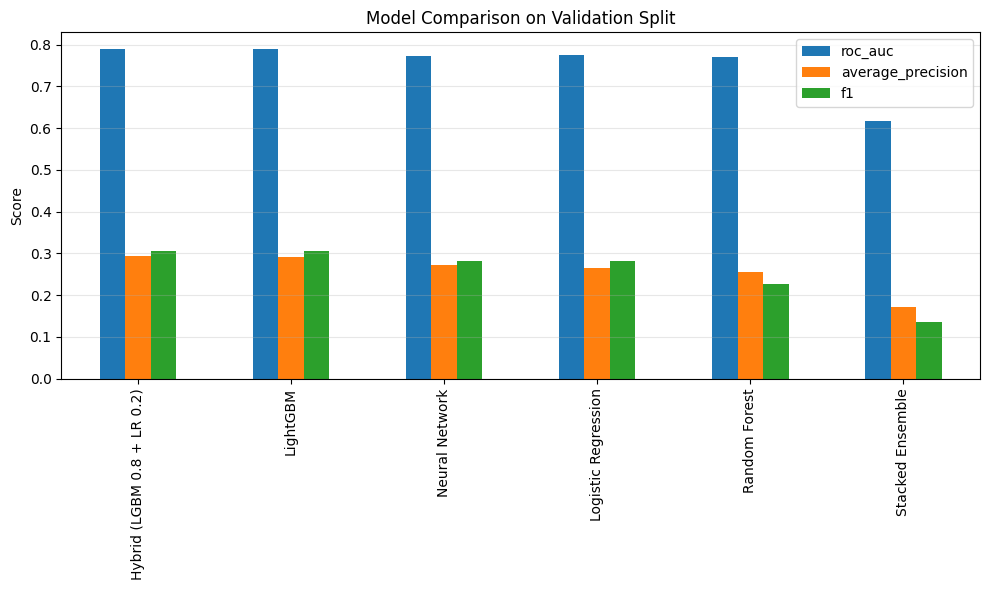

In [18]:
comparison_plot_df = results_df.set_index("model")[["roc_auc", "average_precision", "f1"]]

ax = comparison_plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Model Comparison on Validation Split")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

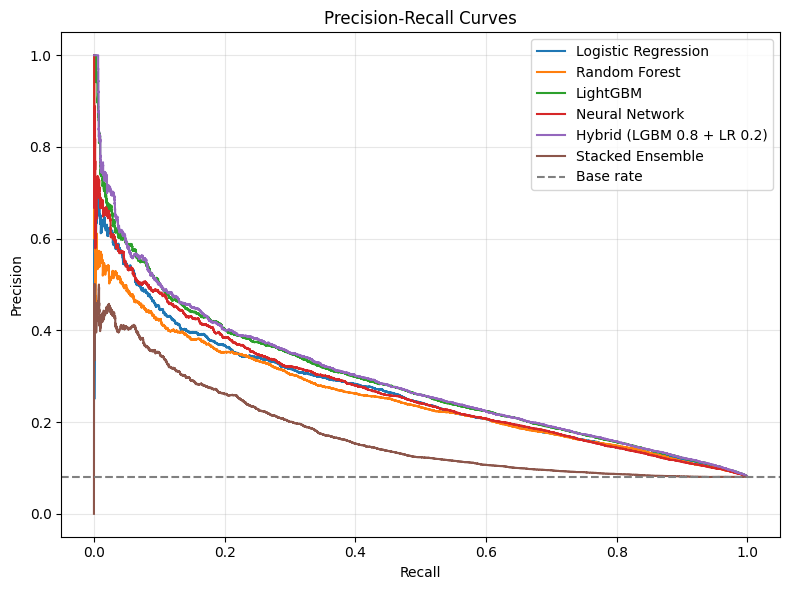

In [19]:
curve_dfs = {
    "Logistic Regression": build_precision_recall_curve_df(y_val_log_reg, log_reg_probs),
    "Random Forest": build_precision_recall_curve_df(y_val_rf, rf_probs),
    "LightGBM": build_precision_recall_curve_df(y_val_lgbm, lgbm_probs),
    "Neural Network": build_precision_recall_curve_df(y_val_mlp, mlp_probs),
    hybrid_results["model"]: build_precision_recall_curve_df(hybrid_y_val, hybrid_probs),
    stacked_results["model"]: build_precision_recall_curve_df(stack_y_val, stack_probs),
}

plt.figure(figsize=(8, 6))
for model_name, curve_df in curve_dfs.items():
    plt.plot(curve_df["recall"], curve_df["precision"], label=model_name)

baseline_precision = y_val_lgbm.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray", label="Base rate")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "precision_recall_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
pd.DataFrame([
    find_threshold_for_target_precision(y_val_lgbm, lgbm_probs, target_precision=0.30),
    find_threshold_for_target_precision(hybrid_y_val, hybrid_probs, target_precision=0.30),
    find_threshold_for_target_precision(stack_y_val, stack_probs, target_precision=0.30),
], index=["LightGBM", hybrid_results["model"], stacked_results["model"]])

,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
LightGBM,0.70,0.880933,0.307855,0.380463,0.340330,0.788850,0.291087
Hybrid (LGBM 0.8 + LR 0.2),0.70,0.881729,0.310084,0.379658,0.341362,0.790146,0.294216
Stacked Ensemble,0.15,0.905436,0.304007,0.132931,0.184978,0.617304,0.171624
